# STEP 4: Transformer Model — Fine-tune RoBERTa

In [2]:
!pip install transformers

   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/10.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/10.5 MB 445.1 kB/s eta 0:00:23
   --- ------------------------------------ 0.8/10.5 MB 649.2 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/10.5 MB 649.2 kB/s eta 0:00:15
   ---- ----------------------------------- 1.0/10.5 MB 716.2 kB/s eta 0:00:14
   ----- ---------------------------------- 1.3/10.5 MB 707.3 kB/s eta 0:00:13
   ----- ---------------------------------- 1.3/10.5 MB 707.3 kB/s eta 0:00:13
   ------ --------------------------------- 1.6/10.5 MB 708.7 kB/s eta 0:00:13
   ------ --------------------------------- 1.6/10.5 MB 708.7 kB/s eta 0:00:13
   ------- -------

  You can safely remove it manually.


In [3]:
import pandas as pd
import numpy as np
import torch
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tqdm import tqdm

In [5]:
# CONFIG
MODEL_NAME  = 'roberta-base'   # swap to 'bert-base-uncased' if GPU memory is limited
MAX_LEN     = 128
BATCH_SIZE  = 16
EPOCHS      = 4
LR          = 2e-5
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cpu


In [7]:
# LOAD DATA
train = pd.read_csv(r'C:\Users\XPRISTO\Desktop\NLP\train.csv')
val   = pd.read_csv(r'C:\Users\XPRISTO\Desktop\NLP\val.csv')
test  = pd.read_csv(r'C:\Users\XPRISTO\Desktop\NLP\test.csv')
le    = joblib.load(r'C:\Users\XPRISTO\Desktop\NLP\label_encoder.pkl')

NUM_CLASSES = len(le.classes_)
print(f"Number of classes: {NUM_CLASSES} → {list(le.classes_)}")

Number of classes: 6 → ['age', 'ethnicity', 'gender', 'not_cyberbullying', 'other_cyberbullying', 'religion']


In [8]:
# DATASET CLASS
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [9]:
# TOKENIZER & DATALOADERS
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = TweetDataset(train['clean_text'], train['label'], tokenizer, MAX_LEN)
val_ds   = TweetDataset(val['clean_text'],   val['label'],   tokenizer, MAX_LEN)
test_ds  = TweetDataset(test['clean_text'],  test['label'],  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

C:\Users\XPRISTO\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\XPRISTO\.cache\huggingface\hub\models--roberta-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [10]:
# MODEL
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES
).to(DEVICE)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
# OPTIMIZER & SCHEDULER
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

In [12]:
# TRAINING LOOP
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(loader, desc='Training'):
        optimizer.zero_grad()

        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc='Evaluating'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), f1, all_preds, all_labels

In [13]:
# TRAIN WITH EARLY STOPPING
history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_val_f1   = 0
patience      = 2
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*50}")
    print(f"Epoch {epoch}/{EPOCHS}")
    print('='*50)

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_f1, _, _ = eval_epoch(model, val_loader, DEVICE)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    print(f"Train Loss : {train_loss:.4f} | Train Acc : {train_acc:.4f}")
    print(f"Val   Loss : {val_loss:.4f}   | Val   F1  : {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(r'C:\Users\XPRISTO\Desktop\NLP\roberta_best')
        tokenizer.save_pretrained(r'C:\Users\XPRISTO\Desktop\NLP\roberta_best')
        print(f" New best model saved (F1={best_val_f1:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break


Epoch 1/4


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 443/443 [10:57<00:00,  1.48s/it]

Train Loss : 0.5928 | Train Acc : 0.7646
Val   Loss : 0.4036   | Val   F1  : 0.8370


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ New best model saved (F1=0.8370)

Epoch 2/4


...

Train Loss : 0.3070 | Train Acc : 0.8775
Val   Loss : 0.3920   | Val   F1  : 0.8546


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ New best model saved (F1=0.8546)

Epoch 4/4


Evaluating: 100%|████████████████████████████████████████████████████████████████████| 443/443 [20:08<00:00,  2.73s/it]

Train Loss : 0.2591 | Train Acc : 0.8986
Val   Loss : 0.4173   | Val   F1  : 0.8531
No improvement. Patience: 1/2


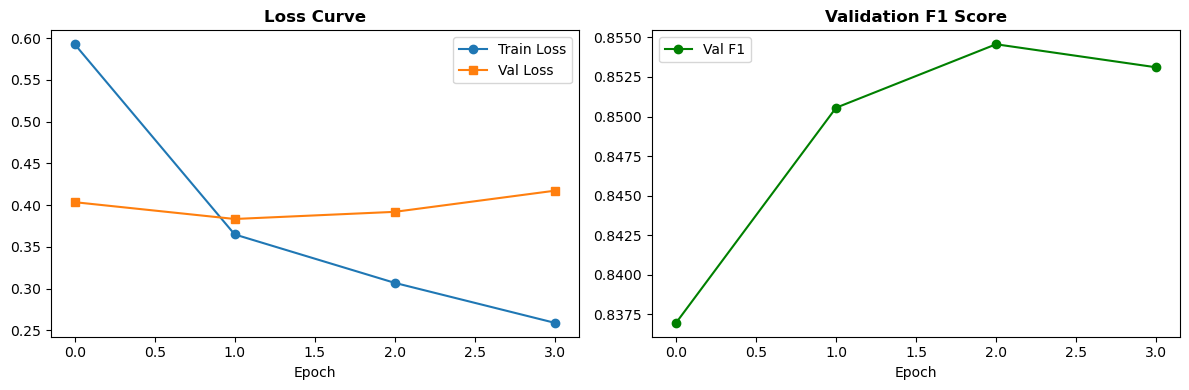

Saved: roberta_learning_curve.png


In [14]:
# LEARNING CURVE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'],   label='Val Loss',   marker='s')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['val_f1'], label='Val F1', color='green', marker='o')
axes[1].set_title('Validation F1 Score', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\XPRISTO\Desktop\NLP\roberta_learning_curve.png', dpi=150)
plt.show()
print("Saved: roberta_learning_curve.png")

In [16]:
# FINAL TEST EVALUATION
print("\n" + "="*50)
print("FINAL TEST EVALUATION")
print("="*50)

# Load best model
best_model = AutoModelForSequenceClassification.from_pretrained(r'C:\Users\XPRISTO\Desktop\NLP\roberta_best').to(DEVICE)
_, test_f1, test_preds, test_labels = eval_epoch(best_model, test_loader, DEVICE)

print(f"\nTest F1 (weighted): {test_f1:.4f}")
print(f"\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=le.classes_))


FINAL TEST EVALUATION


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating: 100%|████████████████████████████████████████████████████████████████████| 443/443 [21:09<00:00,  2.87s/it]


Test F1 (weighted): 0.8443

Classification Report:
                     precision    recall  f1-score   support

                age       0.98      0.97      0.98      1199
          ethnicity       0.97      0.99      0.98      1194
             gender       0.88      0.87      0.88      1191
  not_cyberbullying       0.67      0.53      0.59      1170
other_cyberbullying       0.62      0.73      0.67      1134
           religion       0.94      0.97      0.96      1200

           accuracy                           0.85      7088
          macro avg       0.84      0.84      0.84      7088
       weighted avg       0.85      0.85      0.84      7088



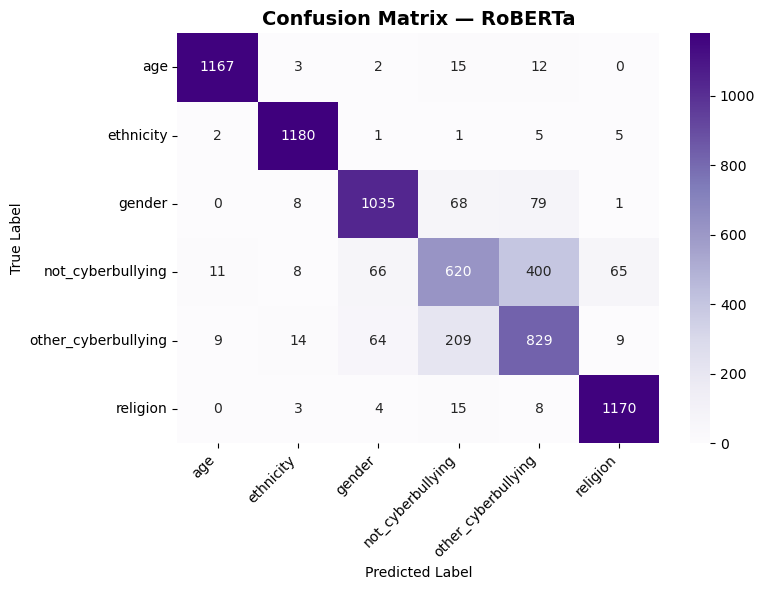

Saved: confusion_matrix_roberta.png

 Transformer training complete.


In [17]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — RoBERTa', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(r'C:\Users\XPRISTO\Desktop\NLP\confusion_matrix_roberta.png', dpi=150)
plt.show()
print("Saved: confusion_matrix_roberta.png")

print("\n Transformer training complete.")